In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容
from extraction import find_一般政策语言_rule_base
import pandas as pd
import matplotlib.pyplot as plt

/Users/ender_yang/opt/anaconda3/envs/lainchain/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_执行过程规定_rule_base(docs,一般政策性内容):
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # We need to standardize the 一般政策性内容 to avoid any characters at the beginning of the sentence
    一般政策性内容 = standerlize_一般政策性内容(一般政策性内容)
    
    # Define keywords for regular expression
    keywords =["(以|用|通过).*?(的方式|方法)","由.*?(主要负责|负责)","流程","程序","执行","分工","牵头","责任","措施","个阶段","进度"]
    pattern = re.compile('|'.join(keywords))
    
    paragraphs = pre_process(docs)
    matched_paragraphs = set()
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        check_paragraph = re.sub(r'\s+', '', paragraph)
        if check_paragraph in 一般政策性内容:
            continue
        if pattern.search(paragraph):
            matched_paragraphs.add((paragraph.strip(), pattern.search(paragraph).group()))

     # Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_执行过程规定_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[15]
docs = open(f'sample/{file_sample}', 'r').read()

$\textbf{Since we need 一般政策性内容 content, so we first extract 一般政策性内容}$

In [5]:
def get_一般政策语言(docs):
    matched_paragraphs_一般政策语言, _ = find_一般政策语言_rule_base(docs)
    一般政策语言_list = []
    for 一般政策语言, _ in matched_paragraphs_一般政策语言:
        一般政策语言_list += [一般政策语言]
        
    return 一般政策语言_list

In [6]:
# we can check the 一般政策语言 content
一般政策语言_list = get_一般政策语言(docs)
print(一般政策语言_list)

['\u3000第一章\u3000总则', '\u3000\u3000第一条\u3000为规范文物房屋征收和流转行为，保障被征收文物房屋所有权人（以下简称被征收人）和流转文物房屋使用权人的合法权益，加强文物房屋保护利用，根据《中华人民共和国民法典》《中华人民共和国文物保护法》《中华人民共和国土地管理法》《中华人民共和国城乡规划法》等法律、法规，参照《中共中央办公厅 国务院办公厅印发关于加强文物保护利用改革的若干意见》、《中共永嘉县委 永嘉县人民政府关于印发＜永嘉县保障性安居工程（四策合一）建设管理试行办法＞的通知》（永委发〔2013〕42号）等文件规定，结合永嘉县文物保护工作实际情况，制定本实施办法', '\u3000\u3000第二条\u3000本办法所称的文物房屋是指县级文物保护单位以上等级的民居类文物建筑', '\u3000\u3000第三条\u3000本办法适用于永嘉县范围内的合法被征收所有权的文物房屋（以下简称被征收房屋，包括经认定视同合法的被征收房屋）的补偿安置，以及对依法流转文物房屋使用权的奖励', '\u3000\u3000第四条\u3000农业户口的被征收房屋所有权人已按政策规定实行安置补偿的，不再享受农村一户一宅的宅基地审批政策']


## Now we can call the function find_执行过程规定_rule_base() ##

In [7]:
matched_paragraphs, matched_paragraphs_index = find_执行过程规定_rule_base(docs, 一般政策语言_list)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [8]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,如被征收房屋建筑占地面积小于20平方米且是被征收人在本村唯一一处住房的，经属地政府牵头协同相关职能部门核实确认后，给予一间地基安置，并按市场评估价格结算差价，具体由属地政府审核把关,牵头
1,《永嘉县文物房屋征收和流转补偿实施办法（试行）》已经县政府第55次常务会议审议通过，现印发给你们，请遵照执行,执行
2,第十二条 未登记权属房屋合法性认定，根据《永嘉县人民政府办公室关于印发永嘉县未登记权属房屋调查认定办法的通知》（永政办发〔2013〕195号）有关规定执行,执行
3,第二十七条 鼓励文物房屋所有人依法向属地政府、国有企业、社会组织流转使用权，租金按当地的市场价格执行，县财政给予出租人适当奖励,执行
4,第九章 职责分工,分工
5,第五章 安置程序,程序
6,第十七条 安置房交付时根据以下办法和程序挂图、分档依次选择认购：,程序
7,第十四条 涉及设有抵押权的被征收房屋，依照国家有关法律规定执行,执行


$\textbf{We can also check where is the sentence}$

In [9]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.4913500
原文链接：https://www.pkulaw.com/lar/a2482b835c318b32a88380fdde68f0d0bdfb.html
永嘉县人民政府办公室关于印发永嘉县文物房屋征收和流转补偿实施办法(试行)的通知
永嘉县人民政府办公室关于印发永嘉县文物房屋征收和流转补偿实施办法（试行）的通知

（永政办发〔2020〕47号）

各功能区管委会，各乡镇（街道）人民政府（办事处），县政府直属各单位：

　　《永嘉县文物房屋征收和流转补偿实施办法（试行）》已经县政府第55次常务会议审议通过，现印发给你们，请遵照执行。
永嘉县人民政府办公室

　　2020年11月9日
永嘉县文物房屋征收和流转补偿实施办法（试行）
　第一章　总则
　　第一条　为规范文物房屋征收和流转行为，保障被征收文物房屋所有权人（以下简称被征收人）和流转文物房屋使用权人的合法权益，加强文物房屋保护利用，根据《中华人民共和国民法典》《中华人民共和国文物保护法》《中华人民共和国土地管理法》《中华人民共和国城乡规划法》等法律、法规，参照《中共中央办公厅 国务院办公厅印发关于加强文物保护利用改革的若干意见》、《中共永嘉县委 永嘉县人民政府关于印发＜永嘉县保障性安居工程（四策合一）建设管理试行办法＞的通知》（永委发〔2013〕42号）等文件规定，结合永嘉县文物保护工作实际情况，制定本实施办法。
　　第二条　本办法所称的文物房屋是指县级文物保护单位以上等级的民居类文物建筑。
　　第三条　本办法适用于永嘉县范围内的合法被征收所有权的文物房屋（以下简称被征收房屋，包括经认定视同合法的被征收房屋）的补偿安置，以及对依法流转文物房屋使用权的奖励。
　　第四条　农业户口的被征收房屋所有权人已按政策规定实行安置补偿的，不再享受农村一户一宅的宅基地审批政策。

　第二章　安置方式与计算标准
　　第五条　被征收房屋实行属地产权安置、货币补偿安置、跨区域异地产权安置、宅基地置换安置（以下简称地基安置）等4种方式，其中地基安置仅限于确因条件限制不能集中安置的零星农民自建房。其他附属配套用房建筑物、构建物（包括道坦）等有文物价值的，需经第三方评估后予以货币补偿。具体根据当地乡镇（街道）提供的安置方式，结合实际情况由被征收人选择其中1种方式安置。
　　第六条　被征收人选择属

## Now we can run batch processing on our sample data ##

In [10]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['File Name', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length', '一般政策语言'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        一般政策语言_list = get_一般政策语言(docs)
        
        matched_paragraphs, matched_paragraphs_index = find_执行过程规定_rule_base(docs, 一般政策语言_list)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list), "\n".join(一般政策语言_list)]
    
    return return_df


In [11]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言
0,吉林保监局关于安邦人寿保险股份有限公司吉林...(FBM-CLI.12.1776690).txt,,,485,0,你公司《安邦人寿保险股份有限公司吉林分公司关于设立安邦人寿保险股份有限公司辽源中心支公司的请示》（安邦寿吉发〔2016〕031号）及其补正材料已收悉。经审查，现通知如下：
1,北京市人民政府办公厅印发《关于在“十三五”...(FBM-CLI.12.1250419).txt,四、保障措施\n落实政府责任，有效动员社会力量，构建多元参与、各有侧重、共建共享的“大救助”工作格局\n建立市、区、街道（乡镇）三级联动的慈善救助网络，完善慈善救助对象发现、推介、救助流程，实现政府救助与慈善救助有效衔接、优势互补\n加强与法院的衔接，制定向法院申请强制执行的程序和规范；完善行政执法与刑事司法衔接机制，对构成犯罪的，及时、规范移送\n健全急难事项求助“首问负责制”和转介工作制度，规范街道（乡镇）服务窗口受理、分办、转办流程\n完善投诉举报核查程序，聘请第三方参与举报核查工作\n结合城镇供热体制改革，加强顶层设计，优化救助程序，对困难家庭给予供暖救助\n开展精准救助逐级督查，选择重点区、重点街道（乡镇）进行重点督查，对政策落实不力的要追究相关单位和人员责任\n对不符合条件的，书面告知申请人并说明理由；对批准享受救助的，书面告知申请人权利义务和应当履行的责任,措施\n责任\n流程\n执行\n流程\n程序\n程序\n责任\n责任,4421,382,为贯彻落实党中央、国务院关于打赢脱贫攻坚战的战略部署，确保率先全面建成小康社会，结合实际，现就本市在“十三五”时期对困难群众实施精准救助提出如下意见\n （一）指导思想\n 深入学习贯彻习近平总书记系列重要讲话和对北京工作的重要指示精神，牢固树立创新、协调、绿色、开放、共享的发展理念，将主动发现、严格管理、精准施救作为工作重点，强化救助响应，拓展服务方式，实现全过程监管，构建政府主导、社会参与的救助体系，切实让困难群众共享改革发展成果
2,山西省林业和草原局关于印发《退耕还林还草作...(FBM-CLI.12.4108330).txt,2.作业设计的小班地块需按照程序经同级自然资源部门核定，并在作业设计审批表上盖章确认\n为进一步规范退耕还林还草管理，满足新时代退耕还林还草事业高质量发展的需要，国家林业和草原局制定了《退耕还林还草作业设计技术规定》和《退耕还林还草档案管理办法》（见附件1、2），请遵照执行,程序\n执行,805,136,为进一步规范退耕还林还草管理，满足新时代退耕还林还草事业高质量发展的需要，国家林业和草原局制定了《退耕还林还草作业设计技术规定》和《退耕还林还草档案管理办法》（见附件1、2），请遵照执行。现提出如下要求：
3,北京市教育委员会、北京市经济和信息化局、北...(FBM-CLI.12.4087809).txt,现予发布，请结合实际，参照执行,执行,480,15,为深入贯彻党的十九大和十九届二中、三中、四中、五中全会精神，认真落实《教育信息化2.0行动计划》《首都教育现代化2035》等部署要求，统筹推进北京教育信息化工作，指导全市中小学校科学规范开展信息化建设，支撑首都教育高质量发展，市教委联合市经济和信息化局、市财政局制定了《北京市中小学校信息化建设规范（试行）》
4,吕梁市住房保障和城乡建设管理局关于转发山西...(FBM-CLI.12.1887683).txt,,,499,0,现将省住建厅晋建市字【2012】289号“山西省住房和城乡建设厅关于开展2012年度建筑业等5类企业动态考核评价工作的通知”转发给你们，建筑业一级、二级及设计施工一体化企业，监理企业，招标代理企业请遵照执行


In [12]:
# We can check if the Retrieve Info is in 一般政策语言
for index, row in df.iterrows():
    if row['Retrieve Info'] == '':
        continue
    
    Retrieve_Info = row['Retrieve Info'].split('\n')
    一般政策语言 = row['一般政策语言'].split('\n')
    
    for info in Retrieve_Info:
        if info in 一般政策语言:
            print(info)

$\textbf{Here we provide some statistics on the results}$

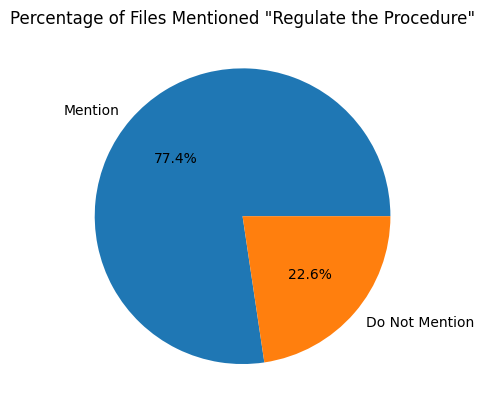

In [13]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "Regulate the Procedure"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

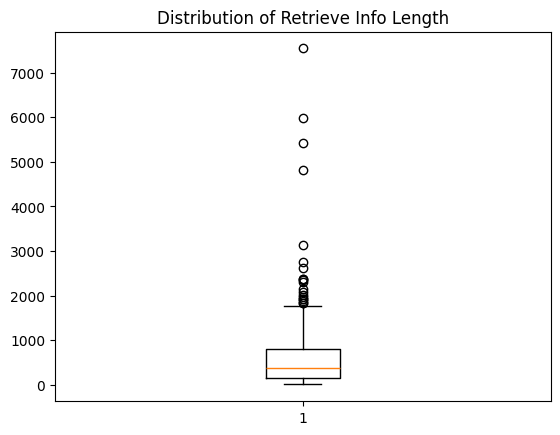

In [14]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

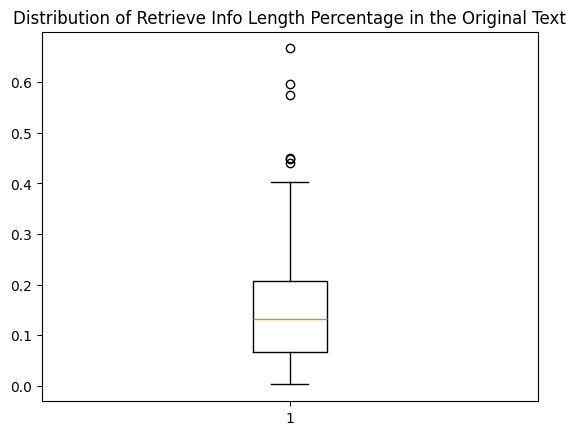

In [15]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [16]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

File Name  \
182       昆明市进一步优化提升营商环境的实施意见(FBM-CLI.12.1523050).txt   
171  绵阳市人民政府关于印发绵阳市推行“证照分离...(FBM-CLI.12.4807696).txt   
340  广元市人民政府关于印发土壤污染防治行动计划...(FBM-CLI.12.1407692).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [17]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
121,厦门市建设局关于印发联合惩戒失信被执行人工...(FBM-CLI.12.1907277).txt,（六）以上惩戒自失信被执行人从各级人民法院失信被执行人信息库中删除之时起终止\n限制失信被执行人申请政府补贴、奖励、扶持资金和社会保障资金支持\n（四）本实施办法未尽事宜，按照中共厦门市委办公厅、厦门市人民政府办公厅印发的《关于加快推进失信被执行人信用监督警示和惩戒机制建设的实施细则》执行\n依法进行招标的工程建设项目，招标人应当在资格预审公告、招标公告、投标邀请书及资格预审文件、招标文件中明确限制失信被执行人参与投标，对失信被执行人的投标活动予以否决\n三、工作任务及责任处室\n（责任单位：市招标办及相关处室）\n在评标阶段，招标人或者招标代理机构、评标专家委员会应当查询投标人是否为失信被执行人（联合体参加投标活动的，应当对所有联合体成员进行失信被执行人信息查询\n（责任单位：房地产开发与物业管理处、建筑业处）\n在职公务员或事业单位工作人员被确定为失信被执行人的，失信情况应作为其评先、评优、晋职晋级的参考\n根据住房城乡建设部办公厅印发的《失信被执行人信用监督、警示和惩戒机制建设分工方案》，中共厦门市委办公厅、厦门市人民政府办公厅印发的《关于加快推进失信被执行人信用监督、警示和惩戒机制建设的实施细则》，国家发改委、最高人民法院等单位联合签署的《关于对失信被执行人实施联合信用惩戒的合作备忘录》及有关政策法规，结合我局工作实际，制定本实施办法\n联合惩戒的对象为厦门市失信被执行人联合惩戒平台公布的失信被执行人\n从厦门市失信被执行人联合惩戒平台获得失信被执行人信息，执行或协助执行本实施办法规定的惩戒措施，将执行情况登记并及时向市中级法院反馈\n联合体包含失信被执行人的，视为失信被执行人），对失信被执行人的投标活动依法予以限制\n（责任单位：各相关处室）\n（责任单位：组织人事处）\n现印发给你们，请按照实施办法，落实联合惩戒失信被执行人工作\n（一）加强组织责任\n具有市场监管职能的处室和单位对列入失信被执行人的企业予以重点监管，按照“双随机一公开”工作机制加大日常监管力度，提高随机抽查的比例和频次，提高监管精准度\n限制失信被执行人及失信被执行人的法定代表人、主要负责人、实际控制人、影响债务履行的直接责任人员申请购买保障性住房\n对列入失信被执行人名单的注册执（从）业人员，作出降低或撤销从业资格、吊销执业资格、限制市场准入等处罚\n（责任单位：社会保障性住房建设与管理办公室、市住房保障管理中心及各相关处室）\n失信被执行人不得作为评标专家参与评标活动，已经作为招标从业人员的，按照有关规定予以处理\n厦门市建设局关于印发联合惩戒失信被执行人工作实施办法的通知\n厦门市建设局联合惩戒失信被执行人工作实施办法\n对列入失信被执行人名单的房地产、建筑企业，依法作出警告、责令限期改正、限制市场准入、暂扣资质证书、降低资质等级或吊销资质证书处理\n依据权力清单、责任清单和负面清单，将失信被执行人信用监督、警示和惩戒信息列入政务公开事项\n各相关处室要对照实施办法细化具体事项，明确责任领导和具体责任人，落实各项任务,执行\n执行\n执行\n执行\n责任\n责任\n执行\n责任\n执行\n执行\n执行\n执行\n执行\n责任\n责任\n执行\n责任\n执行\n执行\n执行\n责任\n执行\n执行\n执行\n执行\n责任\n责任,1872,1248,为推进失信被执行人信用监督、警示和惩戒机制建设，我局结合工作实际，制定《厦门市建设局联合惩戒失信被执行人工作实施办法》,0.666667
138,吉林省安全生产监督管理局关于进一步加强液氨...(FBM-CLI.12.912338).txt,各级安全监管部门、各有关企业要深刻吸取这两起事故教训，切实增强做好当前安全生产工作的责任感和紧迫感，加强液氨、液氯有（剧）毒、刺激性气体生产装置设施的检维修和工艺操作的安全管理，督促企业严格执行冷库建设项目安全设施“三同时”规定，严防泄漏事故发生\n要大力开展危化品安全知识宣传教育工作，及时将氯气的危害信息及应急处置措施告知企业职工和周围群众，不断增强事故防范和应急处置能力，切实保障人民群众生命健康安全，确保我省液氨液氯使用企业安全生产形势稳定\n各地要结合实际，做到警钟长鸣，常住不懈，严防死守，采取更加有效、更加严密、更加得力的工作措施，防范各类涉氯企业生产安全事故发生\n二、立即开展涉氨、氯企业安全生产大检查，切实落实各项安全生产防范措施\n各级安全监管部门要立即组织开展为期一个月的涉氨、氯企业安全生产大检查，要对涉氯企业逐一进行排查，检查的重点为：各涉氨、氯企业是否依法进行安全评价，评价报告是否在有效期内；是否依法设置安全生产管理机构并足额配备安全生产管理人员，特种作业人员是否经安全培训，并经考核合格后持证上岗；企业是否制订完善安全生产责任制，安全生产管理责任是否落实到每个岗位和人员；关键装置、重点部位风险辨识是否到位，安全阀、化工仪表等安全设施是否按照要求及时进行检测、检验和维修保养；工艺技术规程和安全操作规程是否组织专家进行了论证，安全生产管理制度是否能够严格执行；企业重大危险源和重点监控部位的压力、温度、液位等重要参数的自动监控措施是否到位，液化气体、剧毒液体等重点部位的泄漏报警设置和紧急切断装置是否安全可靠，重大危险源及特种设备的监控台账是否健全、规范；生产作业现场是否存在“三违”行为，夜班作业人员是否存在脱岗、离岗、睡岗等行为，节假日期间领导带班值班情况；企业是否按规定制定完善应急救援预案，是否定期进行预案演练，应急救援物资是否充足、完备等内容\n督促企业要严格落实安全生产主体责任，建立健全安全生产责任制及各项安全生产管理规章制度和岗位安全操作规程，加强现场管理、设备管理、重大危险源监控、安全培训教育、隐患排查整改等各项日常安全管理，下大力夯实企业安全生产基层基础工作\n同时，要督促各食品冷藏加工企业，采取有效措施，确保制冷机房与加工间作业人员的有效隔离，确保疏散通道便捷、排风畅通,责任\n措施\n措施\n措施\n责任\n责任\n措施,1609,959,为了深刻吸取事故教训，举一反三，有效防范和坚决遏制类似事故在我省发生，特提出如下要求,0.596022
352,陕西省人民政府办公厅关于印发《陕西省食品安...(FBM-CLI.12.1221927).txt,第十条 乡（镇）人民政府（街道办事处）负责本行政区域的食品安全突发事件应对工作，组织协调、监督检查食品安全监管工作，完善和落实食品安全监管责任制\n第十一条 全省各级人民政府主要负责人对本行政区域的食品安全工作负总责，分管负责人负领导责任；履行食品安全监督管理职责的部门主要负责人对食品安全监督管理工作负直接领导责任，从事监督管理的工作人员负直接监督管理责任\n第二十二条 监察机关或者人事任免机关在做出食品安全行政责任追究决定前，应当听取当事人的陈述和申辩\n对县级食品安全监督管理责任部门主要负责人给予记过处分、分管负责人给予记大过处分；\n《陕西省食品安全行政责任追究办法》已经省政府同意，现印发给你们，请认真贯彻执行\n举报内容经查属实且符合责任追究情形的，应启动行政责任追究程序\n受到食品安全行政责任追究的人员对决定不服的，可依法先进行申诉，对申诉的复查决定不服的，再进行复核\n第二十一条 食品安全监管部门直属的食品检验机构及其食品检验人员出具虚假检验报告的，依照《中华人民共和国食品安全法》第一百三十八条规定，追究检验机构直接负责的主管人员和食品检验人员的责任\n第二十三条 监察机关或者任免机关负责办理食品安全行政责任追究案件的工作人员滥用职权、玩忽职守、徇私舞弊的，依照《行政机关公务员处分条例》进行责任追究，构成犯罪的，移交司法机关\n第十七条 县级以上人民政府未履行本办法第六条所列职责的，对政府主要负责人和直接负责的主管人员给予责任约谈；情节较重的，取消县级人民政府评选先进资格，并予以通报批评；情节严重并造成损害或影响的，对政府主要负责人和直接负责的主管人员给予记过或者记大过处分\n第十八条 县级以上食品安全委员会办公室不履行本办法第七条所列职责的，对其主要负责人进行责任约谈；情节较重的，责令写出书面检查并予以通报批评；情节严重的，暂停其主要负责人职务或者调离工作岗位\n第十九条 县级以上农业、商务、公安、工商行政、质量技术监督、卫生行政、城乡规划建设、城市管理综合行政执法、市容环境、渔业、海关、出入境检验检疫等部门负责食品监管工作的人员不履行职责或者滥用职权、玩忽职守、徇私舞弊的，由监察机关和任免机关按照《行政机关公务员处分条例》《事业单位工作人员处分暂行规定》等进行责任追究，构成犯罪的，移交司法机关；需要实施问责的，依照《关于实行党政领导干部问责的暂行规定》，由纪检监察机关和组织人事部门按照有关规定程序进行责任追究\n应当追究政纪责任的，依照《行政机关公务员处分条例》《事业单位工作人员处分暂行规定》等给予相应的政纪处分\n行政问责按照《关于实行党政领导干部问责的暂行规定》执行\n第二十四条 本办法所指的一般食品安全事件、较大食品安全事件、重大食品安全事件、特别重大食品安全事件的认定标准，按照《陕西省食品安全事件应急预案》的有关规定执行\n对市级食品安全监督管理责任部门分管负责

## We can also comparing the statistics results between two different labels ##

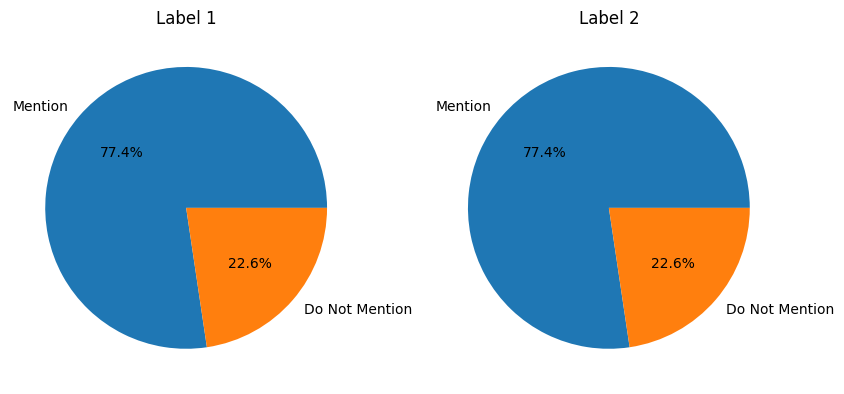

In [18]:
# To achieve this comparison, we need to folder to store the policy data for two labels respectively
# To avoid the relative path issue, We use absolute path here
path_to_folder_label1 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'
path_to_folder_label2 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'

df_label1 = run_batch(path_to_folder_label1)
df_label2 = run_batch(path_to_folder_label2)

# compare two bar chart
is_mention_label1 = len(df_label1[df_label1['Retrieve Info'] != ''])
do_not_mention_label1 = len(df_label1[df_label1['Retrieve Info'] == ''])
is_mention_label2 = len(df_label2[df_label2['Retrieve Info'] != ''])
do_not_mention_label2 = len(df_label2[df_label2['Retrieve Info'] == ''])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pie([is_mention_label1, do_not_mention_label1], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[0].set_title('Label 1')
ax[1].pie([is_mention_label2, do_not_mention_label2], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[1].set_title('Label 2')
plt.show()

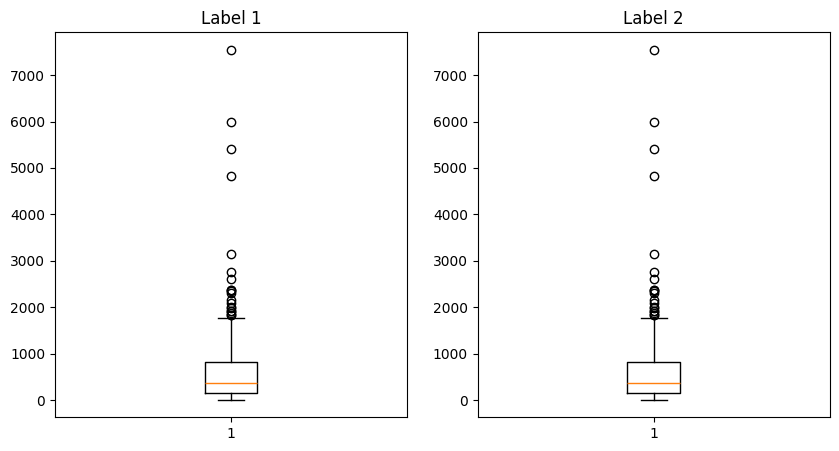

In [19]:
# We can also compare the distribution of retrieve info length
df_label1 = df_label1[df_label1['Retrieve Info'] != '']
df_label2 = df_label2[df_label2['Retrieve Info'] != '']

retrieve_info_length_label1 = df_label1['Retrieve Info'].apply(lambda x: len(x))
retrieve_info_length_label2 = df_label2['Retrieve Info'].apply(lambda x: len(x))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(retrieve_info_length_label1)
ax[0].set_title('Label 1')
ax[1].boxplot(retrieve_info_length_label2)
ax[1].set_title('Label 2')
plt.show()

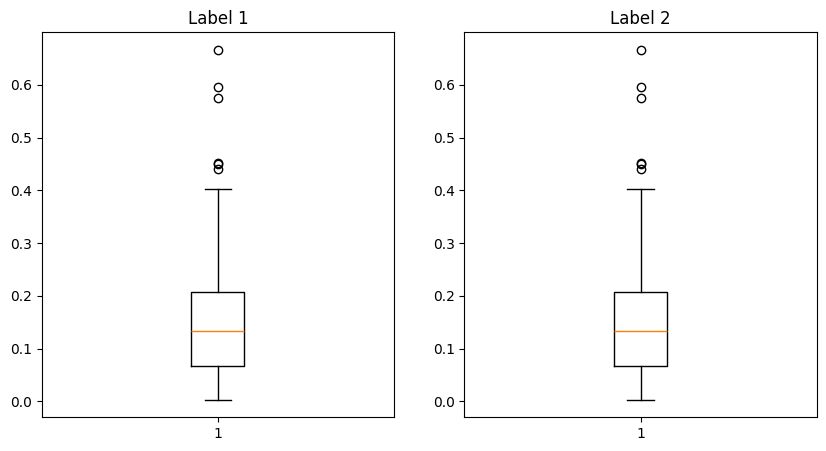

In [20]:
df_label1['Retrieve Info Length Percentage'] = df_label1['Retrieve Info Length'] / df_label1['Original Text Length']
df_label2['Retrieve Info Length Percentage'] = df_label2['Retrieve Info Length'] / df_label2['Original Text Length']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(df_label1['Retrieve Info Length Percentage'])
ax[0].set_title('Label 1')
ax[1].boxplot(df_label2['Retrieve Info Length Percentage'])
ax[1].set_title('Label 2')
plt.show()